(1000, 784)
97


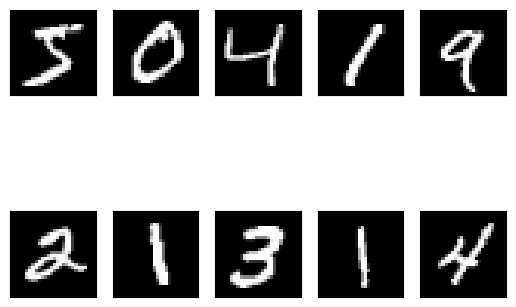

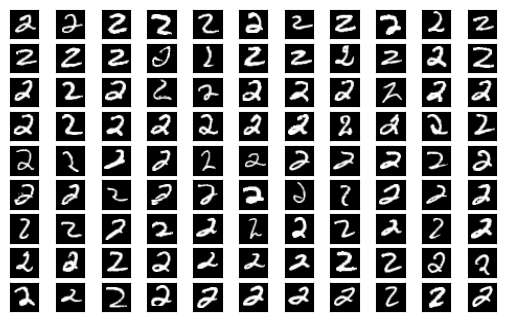

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', data_home='./', return_X_y=True)                               # download the data
X = X / 255.                                                                                    # do data normalization

# it creates mldata folder in your root project folder
# rescale the data, use the traditional train/test split
# X_train, X_test = X[:60000], X[60000:]                                                        
# y_train, y_test = y[:60000], y[60000:]
X_small = X[:1000]                                                                              # obtain the first thousand data
y_small = y[:1000]                                                                              # obtain the first thousand label

print(X_small.shape)

print(len(np.nonzero(y_small.values.astype('int') == 0)[0]))


# display the first 10 digits in the training set
plt.figure()                                                                            
for i in range(10):                                                                             # draw 10 pictures
    plt.subplot(2, 5, i+1)                                                                      # set the subplot id
    plt.imshow(X_small.loc[i].values.reshape((28, 28)), cmap='gray')                            # convert the one dimentional data into two dimentional image
    plt.xticks([]), plt.yticks([])                                                              # delete the x axis and y axis scale
plt.show()


num_of_sample = []
for i in range(10):
    num_of_sample.append(len(np.nonzero(y_small.values.astype('int') == i)[0]))                 # count the number of sampled per category       

# If you want to display all the samples for a specific digit (take '2' for example), the
# following command might help:

plt.figure()
index = np.nonzero(y_small.values.astype('int') == 2)[0]                                       # count the total number of image with label == 2
    
for i in range(len(index)):                                                                     # draw the image in size of 11*11
    plt.subplot(11, 11, i+1)
    plt.imshow(X_small.loc[index[i]].values.reshape(28, 28), cmap='gray')
    plt.xticks([]), plt.yticks([])                                                              # delete the axis scale
plt.show()


X_small_norm = np.zeros(X_small.values.shape)                                                   # normalization -- x = (x-mean(x)) / std(x)
for i in range(X_small.shape[0]):
    X_small_norm[i, :] = (X_small.loc[i].values - np.mean(X_small.loc[i].values)) / np.std(X_small.loc[i].values)   #normalization equation

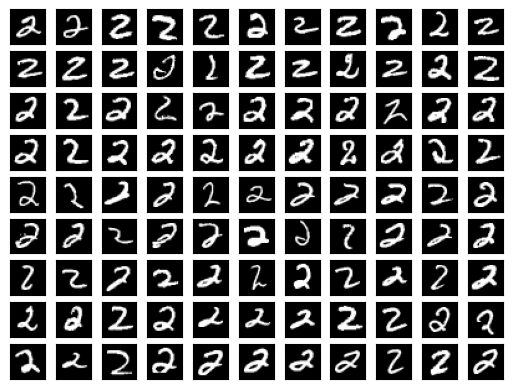

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier

'''
    Task 1: Play with MNIST
'''

X, y = fetch_openml('mnist_784', data_home='./', return_X_y=True)
X = X / 255

# sub-task2: save the first 1000 data in both X and y using savez
#			 load the saved file in the subsequent running using load

X_small = X[:1000]
y_small = y[:1000]
X_small = X_small.values
y_small = y_small.values

np.savez('1k.npz', X_small=X_small, y_small=y_small)

'''
	Example: load compressed data again

	data = np.load('1k.npz')
	X_small = data['X_small']
	y_small = data['y_small']
'''

# sub-task3: count the number of images for each class
index = np.nonzero(y_small == '2')[0]

row = 9
column = 11
counter = 0

for _ in range(row):
    for _ in range(column):
        plt.subplot(row, column, counter + 1)
        x = X_small[index[counter]]  # retrieve img feature by index
        x = x.reshape(28, 28)  # reshape x from vector to matrix
        plt.imshow(x, cmap='gray')
        plt.xticks([])
        plt.yticks([])
        counter += 1
plt.show()



In [4]:
'''lab2-ans-code'''
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier

'''
    Task: solve handwritten digit recognition by instance based learning technique (KNN)
'''

data = np.load('1k.npz', allow_pickle=True)
X_small = data['X_small']
y_small = data['y_small']
index = np.nonzero(y_small == '2')[0]
te_feats = [X_small[i] for i in index]

knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_small, y_small)  # Fit the model using X_small as training data and y_small as target values
prediction = knn.predict(te_feats)  # Predict the class labels for te_feats (i.e. first 99 images of digit 2)
print(prediction)

['2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '1' '2' '2'
 '2' '2' '2' '2' '2' '2' '2' '1' '2' '2' '2' '2' '1' '2' '2' '2' '2' '2'
 '2' '2' '2' '2' '2' '2' '2' '2' '2' '1' '2' '2' '2' '2' '2' '2' '2' '2'
 '2' '2' '2' '2' '2' '2' '2' '0' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2'
 '2' '2' '2' '1' '2' '2' '0' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2'
 '2' '2' '2' '2' '2' '2' '2' '2' '2']
